In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import nd2
from ipywidgets import interact, IntSlider, widgets
import matplotlib.pyplot as plt
from IPython.display import display
from ipywidgets import interactive_output
import tifffile as tiff
from scipy import ndimage

# Metadata
RFP -> Exposuretime is 400ms
GFP -> Exposuretime is 60ms
BF -> Exposuretime is 60ms

to substract the background we are using .tif images, where the shutter of the camera is closed

In [9]:
dark_400 = tiff.imread("/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20210531 Darkfield 400ms.tif").astype(np.float32)
dark_60 = tiff.imread("/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20210531 Darkfield 60ms.tif").astype(np.float32)

print(dark_400.shape)
print(dark_60.dtype)

(600, 600)
float32


# showing the raw Cell Images
0 -> RFP
1 -> GFP
2 -> BF

In [17]:
og_file = "/Volumes/TAYLOR-LAB/Huyen Anh /20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001/20221216 3nM 231-A8_NEMO_TRAF6_1um_38mol 001.nd2"
my_array = nd2.imread(og_file)
my_file = nd2.ND2File(og_file)
my_file.shape

channel_names = ["Red", "GFP", "BF"]

def show_frame(t):

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    #[Red]
    axes[0].imshow(
        my_array[t, 0],
        cmap="magma",
        vmin=0,
        vmax=500
    )
    axes[0].set_title("mScarlet")
    axes[0].axis("off")

    #[GFP]
    axes[1].imshow(
        my_array[t, 1],
        cmap="viridis",
        vmin=0,
        vmax=200
    )
    axes[1].set_title("GFP")
    axes[1].axis("off")

    #[Brightfield]
    axes[2].imshow(
        my_array[t, 2],
        cmap="gray"
        
    )
    axes[2].set_title("BF")
    axes[2].axis("off")

    plt.suptitle(f"Timepoint {t}")
    plt.tight_layout()
    plt.show()

play = widgets.Play(
    value=0,
    min=0,
    max=my_array.shape[0]-1,
    step=1,
    interval=3,      # ms/frame
)
slider = widgets.IntSlider(
    min=0,
    max=my_array.shape[0]-1,
    step=1,
    value=300,
    description="Time"
)

# Link play button to slider
widgets.jslink((play, 'value'), (slider, 'value'))

# Display
ui = widgets.HBox([play, slider])
out = interactive_output(show_frame, {'t': slider})

display(ui, out)

/var/folders/2q/qj12d6zd1qg4x5blqbp5z8fc0000gn/T/ipykernel_74714/1273673672.py:3: UserWarning: ND2File file not closed before garbage collection. Please use `with ND2File(...):` context or call `.close()`.
  my_file = nd2.ND2File(og_file)


Output()

# Backgroundsubstracting
substrating dark_frame with the associated channels

In [ ]:
rfp_raw = my_array[:,0].astype(np.float32)
gfp_raw = my_array[:,1].astype(np.float32)
bf_raw = my_array[:,2].astype(np.float32)

# np.clip() -> I >= 0, makes sure that every pixel is equal or larger than zero
# Dark-frame subtraction
rfp_pre1 = np.clip(rfp_raw - dark_400, 0, None)
gfp_pre1 = np.clip(gfp_raw - dark_60, 0, None)
bf_pre1  = np.clip(bf_raw - dark_60, 0, None)

def show_pre1(t):

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # RFP
    axes[0].imshow(
        rfp_pre1[t],
        cmap="magma",
        vmin=0,
        vmax=500
    )
    axes[0].set_title("mScarlet (dark-frame corrected)")
    axes[0].axis("off")

    # GFP
    axes[1].imshow(
        gfp_pre1[t],
        cmap="viridis",
        vmin=0,
        vmax=200
    )
    axes[1].set_title("GFP (dark-frame corrected)")
    axes[1].axis("off")

    # Brightfield
    axes[2].imshow(
        bf_pre1[t],
        cmap="gray"
    )
    axes[2].set_title("Brightfield")
    axes[2].axis("off")

    plt.suptitle(f"Timepoint {t}")
    plt.tight_layout()
    plt.show()

play = widgets.Play(
    value=0,
    min=0,
    max=rfp_pre1.shape[0]-1,
    step=1,
    interval=3      # ms/frame
)

slider = widgets.IntSlider(
    value=300,
    min=0,
    max=rfp_pre1.shape[0]-1,
    step=1,
    description="Time"
)

widgets.jslink((play, "value"), (slider, "value"))

ui = widgets.HBox([play, slider])
out = interactive_output(show_pre1, {"t": slider})

display(ui, out)

Output()

## now i am doing this blurry thing just like the taylor lab
median blur\
removing median blur (?)

Text(0.5, 1.0, 'Original - Median')

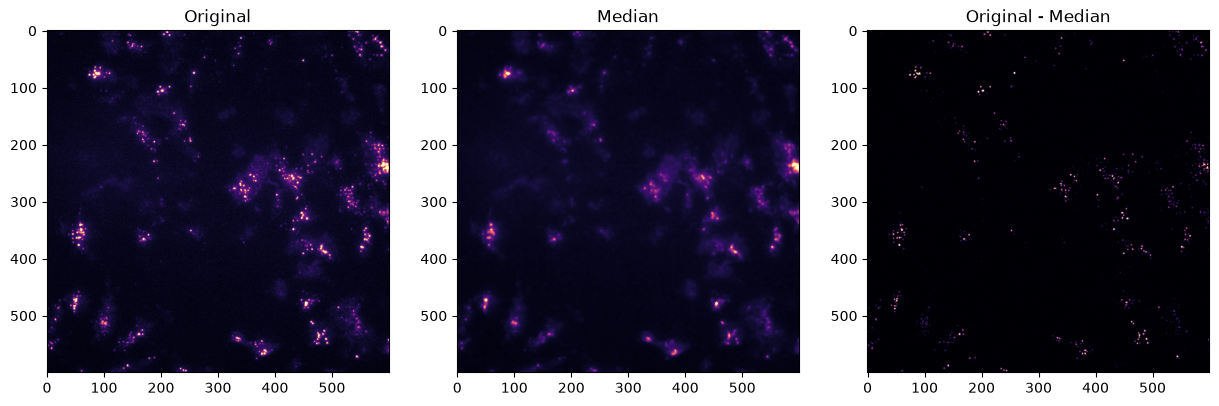

In [19]:
med = ndimage.median_filter(rfp_pre1[300], size=5)
rfp_med = rfp_pre1[300] - np.minimum(med, rfp_pre1[300])
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rfp_pre1[300], cmap="magma", vmin=0, vmax=500)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(med, cmap="magma", vmin=0, vmax=500)
plt.title("Median")

plt.subplot(1,3,3)
plt.imshow(rfp_med, cmap="magma", vmin=0, vmax=500)
plt.title("Original - Median")

### applying to the whole 3D image

In [20]:
def median_background_subtraction(movie, size=5):
    result = np.empty_like(movie)

    for t in range(movie.shape[0]):

        background = ndimage.median_filter(movie[t], size=size)

        result[t] = movie[t] - np.minimum(background, movie[t])

    return result

rfp_pre2 = median_background_subtraction(rfp_pre1)
gfp_pre2 = median_background_subtraction(gfp_pre1)

In [ ]:
def show_pre2(t):

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # RFP
    axes[0].imshow(
        rfp_pre2[t],
        cmap="magma",
        vmin=0,
        vmax=500
    )
    axes[0].set_title("mScarlet (dark-frame corrected)")
    axes[0].axis("off")

    # GFP
    axes[1].imshow(
        gfp_pre2[t],
        cmap="viridis",
        vmin=0,
        vmax=200
    )
    axes[1].set_title("GFP (dark-frame corrected)")
    axes[1].axis("off")

play = widgets.Play(
    value=0,
    min=0,
    max=rfp_pre2.shape[0]-1,
    step=1,
    interval=3      # ms/frame
)

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=rfp_pre2.shape[0]-1,
    step=1,
    description="Time"
)

widgets.jslink((play, "value"), (slider, "value"))

ui = widgets.HBox([play, slider])
out = interactive_output(show_pre2, {"t": slider})

display(ui, out)

Output()

# Morphological opening (White Hat)
Removing small objects in grayscale images with a top hat filter
This example shows how to remove small objects from grayscale images. The top-hat transform [1] is an operation that extracts small elements and details from given images. Here we use a white top-hat transform, which is defined as the difference between the input image and its (mathematical morphology) opening.\
disk size 

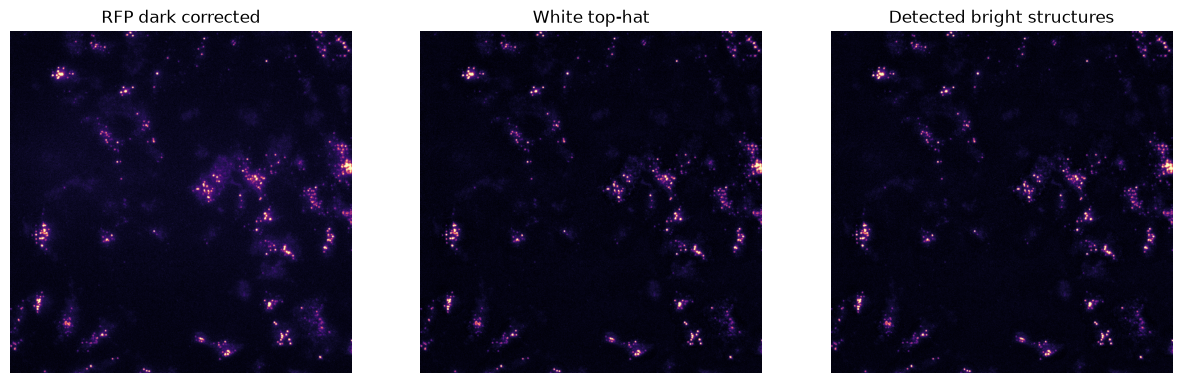

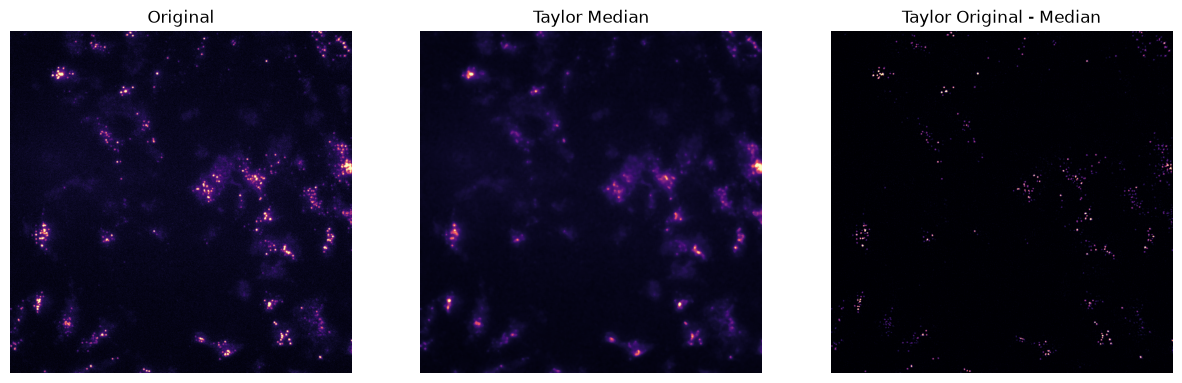

In [32]:
from skimage.morphology import white_tophat, disk
frame = rfp_pre1[300]

# choose the size of the structuring element
selem = disk(20)

rfp_tophat_300 = white_tophat(frame, footprint=selem)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(frame, cmap="magma", vmin=0, vmax=500)
plt.title("RFP dark corrected")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(white_tophat(frame, footprint=selem), cmap="magma", vmin=0, vmax=500)
plt.title("White top-hat")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rfp_tophat_300, cmap="magma", vmin=0, vmax=500)
plt.title("Detected bright structures")
plt.axis("off")

plt.show()

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(rfp_pre1[300], cmap="magma", vmin=0, vmax=500)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(med, cmap="magma", vmin=0, vmax=500)
plt.title("Taylor Median")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rfp_med, cmap="magma", vmin=0, vmax=500)
plt.title("Taylor Original - Median")
plt.axis("off")

plt.show()